In [1]:
import tensorflow as tf
print(tf.test.is_gpu_available())
print(tf.config.list_physical_devices('GPU'))

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
True
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Check if TensorFlow is detecting the GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if len(gpus) > 0:
    print(f"Found {len(gpus)} GPU(s). Using GPU.")
    # Optionally, set GPU memory growth to avoid allocating all memory at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPUs found. TensorFlow is using the CPU.")


Found 1 GPU(s). Using GPU.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [4]:
# 1) Load your data and label-encode the 'Condition' column
###############################################################################
data = pd.read_excel("D:/Ruslan/main.xlsx")  # Adjust path if needed
print(data.head())
print("Unique conditions (raw):", data['Condition'].unique())

labelencoder = LabelEncoder()
data['Condition'] = labelencoder.fit_transform(data['Condition'])
print("Unique conditions (encoded):", data['Condition'].unique())

   IMG name  Voltage, V  Current, A Condition
0         1       20.21       2.000     clean
1         2       20.27       2.006     clean
2         3       20.33       2.010     clean
3         4       20.33       2.009     clean
4         5       20.32       2.007     clean
Unique conditions (raw): ['clean' 'water' 'dust' 'snow']
Unique conditions (encoded): [0 3 1 2]


In [5]:
# 2) Construct full file paths for images and store in 'ImagePath'
###############################################################################
image_dir = "D:/Ruslan/main/"  # Adjust if needed
data['ImagePath'] = data['IMG name'].apply(
    lambda x: os.path.join(image_dir, f"{x}.jpg")
)
print(data[['IMG name','Condition','ImagePath']].head())

   IMG name  Condition             ImagePath
0         1          0  D:/Ruslan/main/1.jpg
1         2          0  D:/Ruslan/main/2.jpg
2         3          0  D:/Ruslan/main/3.jpg
3         4          0  D:/Ruslan/main/4.jpg
4         5          0  D:/Ruslan/main/5.jpg


In [6]:
# 3) Custom split logic: train_val vs. test, based on condition & IMG name
###############################################################################
def assign_split(row):
    img_name = row['IMG name']
    cond = row['Condition']

    # Hard-coded split logic (clean = 0, dust = 1, snow = 2, water = 3)
    if cond == 0:  # clean
        if 428 <= img_name <= 603:
            return 'test'
        else:
            return 'train_val'
    elif cond == 3:  # water
        if 1006 <= img_name <= 1156:
            return 'test'
        else:
            return 'train_val'
    elif cond == 1:  # dust
        if 2901 <= img_name <= 3029:
            return 'test'
        else:
            return 'train_val'
    elif cond == 2:  # snow
        if 3370 <= img_name <= 3630:
            return 'test'
        else:
            return 'train_val'
    else:
        return 'train_val'

data['Split'] = data.apply(assign_split, axis=1)

test_data = data[data['Split'] == 'test'].copy()
train_val_data = data[data['Split'] == 'train_val'].copy()

In [7]:
# 4) Split train_val_data -> train + val (stratified by condition)
###############################################################################
train_data, val_data = train_test_split(
    train_val_data,
    test_size=0.1875,  # so that test_data is ~18.4% + val ~15.29%, train ~66.255%
    random_state=42,
    stratify=train_val_data['Condition']
)

print("Train data size:", train_data.shape[0])
print("Validation data size:", val_data.shape[0])
print("Test data size:", test_data.shape[0])

Train data size: 2846
Validation data size: 657
Test data size: 717


In [8]:
# 5) Prepare tf.data Datasets
###############################################################################
IMG_SIZE = (224, 224)

def load_image_and_labels(filename, condition, augment=False):
    """
    Load + decode + resize. If augment=True, apply optional data augmentation.
    Returns (image, label).
    """
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    # condition is an integer [0..3], for 4 classes
    condition = tf.cast(condition, tf.int32)

    return image, condition

def df_to_dataset(df, shuffle=True, batch_size=32, augment=False):
    filenames = df['ImagePath'].values
    conditions = df['Condition'].values

    ds = tf.data.Dataset.from_tensor_slices((filenames, conditions))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)
    ds = ds.map(lambda f, c: load_image_and_labels(f, c, augment=augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Create the datasets
train_ds = df_to_dataset(train_data, shuffle=True,  batch_size=32, augment=False)
val_ds   = df_to_dataset(val_data,   shuffle=False, batch_size=32, augment=False)
test_ds  = df_to_dataset(test_data,  shuffle=False, batch_size=32, augment=False)

In [9]:
def preact_basic_block(x, filters, stride=1, downsample=False, name="preact_block"):
    """
    A single pre-activation residual block for ResNet-6 (ResNet v2 style).
    """
    shortcut = x  # Keep original for skip-connection

    # First pre-activation: BN -> ReLU
    x = layers.BatchNormalization(name=name + "_bn1")(x)
    x = layers.ReLU(name=name + "_relu1")(x)

    # If downsampling, also apply a 1x1 conv to the shortcut
    if downsample:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride,
                                 padding='same', use_bias=False,
                                 name=name + "_0_conv")(x)

    # First 3×3 conv
    x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same',
                      use_bias=False, name=name + "_conv1")(x)

    # Second pre-activation: BN -> ReLU
    x = layers.BatchNormalization(name=name + "_bn2")(x)
    x = layers.ReLU(name=name + "_relu2")(x)

    # Second 3×3 conv (stride=1)
    x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same',
                      use_bias=False, name=name + "_conv2")(x)

    # Add the shortcut
    x = layers.Add(name=name + "_add")([x, shortcut])
    return x

In [10]:
# 7) Build the full ResNet-6 (pre-activation) Model
###############################################################################
def build_resnet6_pre_activation(input_shape=(224, 224, 3), num_classes=4):
    """
    Builds a ResNet-6 with pre-activation residual blocks (ResNet v2 style).
    """
    inputs = layers.Input(shape=input_shape)

    # Initial Conv (7×7, stride=2) + BN + ReLU + MaxPool(3×3, stride=2)
    x = layers.Conv2D(64, kernel_size=7, strides=2, padding='same',
                      use_bias=False, name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same', name="maxpool1")(x)

    # For ResNet-6: 1 stage, with 2 blocks, second stage with 1 block, third stage with 0 block, last stage with 0 block
    filters_list = [64, 128, 256, 512]
    blocks_per_stage = [2, 0, 0, 0]

    for stage_idx, (filters, num_blocks) in enumerate(zip(filters_list, blocks_per_stage)):
        for block_idx in range(num_blocks):
            # Downsample on the first block of each stage > 0
            stride = 2 if (block_idx == 0 and stage_idx > 0) else 1
            downsample = True if (block_idx == 0 and stage_idx > 0) else False

            block_name = f"stage{stage_idx+1}_block{block_idx+1}"
            x = preact_basic_block(
                x, filters=filters, stride=stride,
                downsample=downsample, name=block_name
            )

    # Final BN + ReLU
    x = layers.BatchNormalization(name="bn_final")(x)
    x = layers.ReLU(name="relu_final")(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D(name="gap")(x)

    # Classification head
    outputs = layers.Dense(num_classes, activation='softmax', name="fc")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="ResNet6_Preact")
    return model

In [11]:
# 8) Instantiate and Compile the Model
###############################################################################
model = build_resnet6_pre_activation(input_shape=(224, 224, 3), num_classes=4)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy()]
)

model.summary()

Model: "ResNet6_Preact"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1 (Conv2D)                 (None, 112, 112, 64  9408        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn1 (BatchNormalization)       (None, 112, 112, 64  256         ['conv1[0][0]']                  
                                )                                                    

In [12]:
# 9) Set up callbacks (checkpoints and early stopping)
###############################################################################
save_dir = "D:/Ruslan/ModelWeights/"
os.makedirs(save_dir, exist_ok=True)
weights_path = os.path.join(save_dir, "resnet6_preact_weights_epoch200_224x224.h5")
checkpoint_cb = ModelCheckpoint(
    filepath=weights_path,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=200,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# 10) Train the model
###############################################################################
with tf.device('/GPU:0'):
    history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/200
89/89 [==============================] - ETA: 0s - loss: 0.7914 - sparse_categorical_accuracy: 0.7270
Epoch 1: val_loss improved from inf to 1.57360, saving model to D:/Ruslan/ModelWeights\resnet6_preact_weights_epoch200_224x224.h5
89/89 [==============================] - 216s 2s/step - loss: 0.7914 - sparse_categorical_accuracy: 0.7270 - val_loss: 1.5736 - val_sparse_categorical_accuracy: 0.2648
Epoch 2/200
89/89 [==============================] - ETA: 0s - loss: 0.3961 - sparse_categorical_accuracy: 0.9083
Epoch 2: val_loss did not improve from 1.57360
89/89 [==============================] - 215s 2s/step - loss: 0.3961 - sparse_categorical_accuracy: 0.9083 - val_loss: 2.3471 - val_sparse_categorical_accuracy: 0.2648
Epoch 3/200
89/89 [==============================] - ETA: 0s - loss: 0.2947 - sparse_categorical_accuracy: 0.9368
Epoch 3: val_loss did not improve from 1.57360
89/89 [==============================] - 215s 2s/step - loss: 0.2947 - sparse_categorical_accuracy

In [14]:
# 11) Evaluate the model on the test set
###############################################################################
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

23/23 [==============================] - 43s 2s/step - loss: 1.4402 - sparse_categorical_accuracy: 0.8480
Test Loss: 1.4402, Test Accuracy: 0.8480


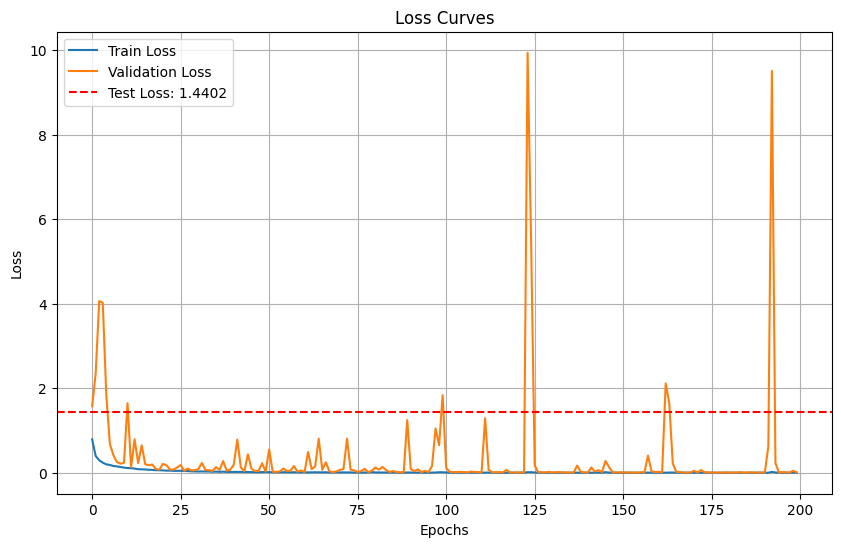

In [15]:
# 12) Plot training and validation loss
###############################################################################
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

# Evaluate once more for a line on the chart
plt.axhline(test_loss, color='red', linestyle='--', label=f'Test Loss: {test_loss:.4f}')
plt.title('Loss Curves')
plt.xlabel('Epochs') 
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

1/1 [==============================] - 0s 255ms/step


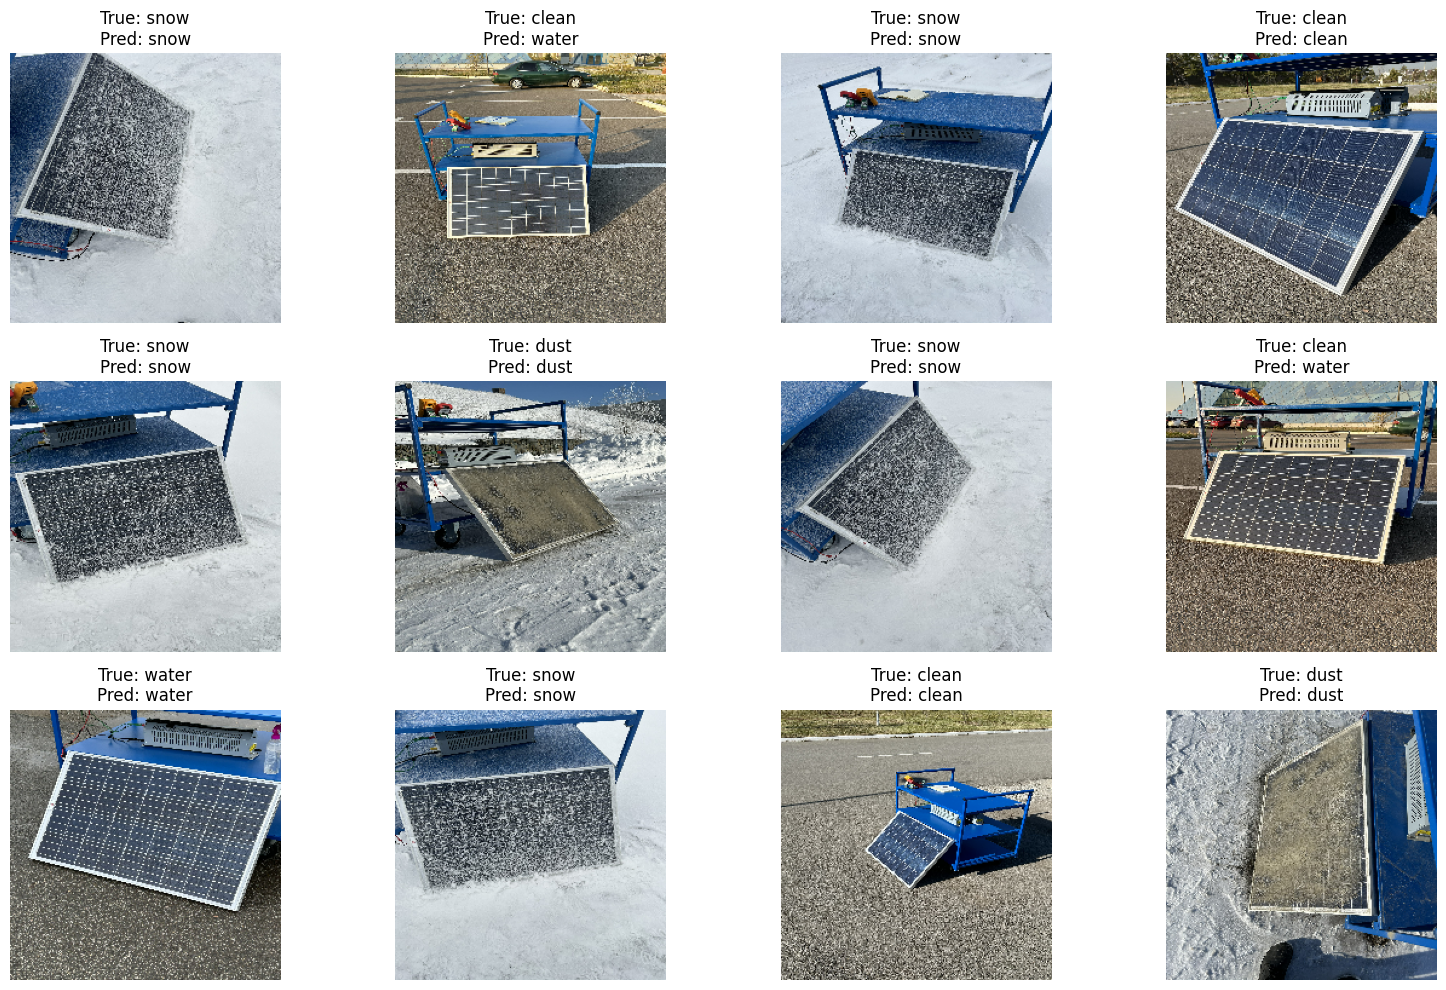

In [16]:
# 13) Show sample predictions
###############################################################################
def show_sample_predictions(test_ds, model, sample_count=12):
    """
    Display 'sample_count' images from test_ds, showing true vs. predicted labels.
    """
    class_names = ["clean", "dust", "snow", "water"]  # Make sure this matches your encoding

    images, labels, preds = [], [], []
    count = 0

    for image_batch, label_batch in test_ds:
        predictions = model.predict(image_batch)
        pred_classes = tf.argmax(predictions, axis=1)

        for i in range(image_batch.shape[0]):
            if count >= sample_count:
                break
            images.append(image_batch[i].numpy())
            labels.append(label_batch[i].numpy())
            preds.append(pred_classes[i].numpy())
            count += 1

        if count >= sample_count:
            break

    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))
    axes = axes.flatten()

    for idx, ax in enumerate(axes[:sample_count]):
        ax.imshow(images[idx])
        ax.axis('off')
        true_label = class_names[labels[idx]]
        pred_label = class_names[preds[idx]]
        ax.set_title(f"True: {true_label}\nPred: {pred_label}")

    plt.tight_layout()
    plt.show()

# Shuffle the test dataset once more for random display
test_ds_shuffled = df_to_dataset(test_data, shuffle=True, batch_size=32, augment=False)
show_sample_predictions(test_ds_shuffled, model, sample_count=12)
